In [1]:
import sys

In [2]:
# %%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    %cd '/content/drive/MyDrive/structure-loss-classification/'
    %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/g/My Drive/types/"
    my_local_data_struct = "/mnt/g/My Drive/types-struct/"

In [3]:
my_local_data

'/mnt/g/My Drive/types/'

In [4]:
import torch
import torch.nn as nn

import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision.models.feature_extraction import (
    get_graph_node_names,
    create_feature_extractor,
)

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [6]:
import pytorch_lightning as pl

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "notebook", "grid"])

In [8]:
import pickle

In [9]:
from models.models import LeNet5
from lightning_modules.lightning_modules import LitLeNet5
from visualization.filters import display_filters
from visualization.display import process_plot_image
from datasets.data_modules import CustomImageDataModule
from train.train import get_features, train_model
from hyperparameter_tuning.tune import HyperParameterTuner
from datasets.datasets import CustomImageFolder

In [10]:
toTensorAndNormalize = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
    ]
)
aux_data = datasets.ImageFolder(root=my_local_data, transform=toTensorAndNormalize)

In [11]:
from ray import tune

In [12]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset


In [13]:

aux_data = CustomImageFolder(
    root_dir=my_local_data,
    classification_mode="binary",
    transform=toTensorAndNormalize,
)

In [14]:
aux_data.label_map

{0: 0, 1: 1, 2: 1, 3: 1}

In [15]:
aux_data.dataset.class_to_idx

{'goodIngots': 0, 'typeA': 1, 'typeB': 2, 'typeC': 3}

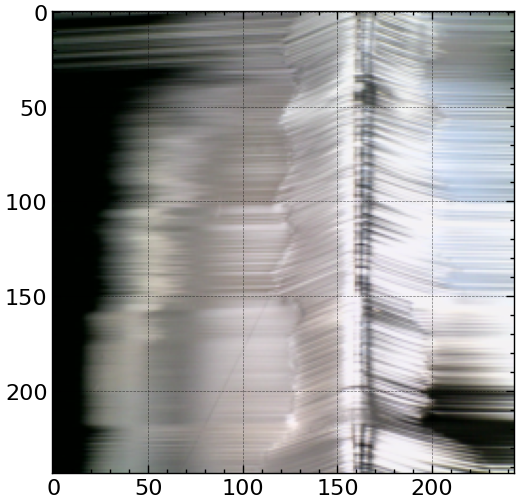

In [16]:
process_plot_image(aux_data, 98, plot=True)

In [17]:
# Try to load cached targets first
try:
    with open(f"logdir/cached_targets.pkl", "rb") as f:
        targets = pickle.load(f)
except FileNotFoundError:
    targets = [t for _, t in aux_data]
    # Cache the targets for next time
    with open(f"logdir/cached_targets.pkl", "wb") as f:
        pickle.dump(targets, f)

In [18]:
model2 = LitLeNet5(num_classes=2, size_layer_1=10, size_layer_2=5, learning_rate=0.001)

In [19]:
kfold = StratifiedKFold(
    n_splits=4,
    shuffle=True,
)

In [20]:
validation_metrics = []

In [21]:
trainer_config = {
    "patience": 3,
    "accelerator": "gpu",
    "devices": -1,
    "max_epochs": 10,
    "precision": 32,
    "n_steps": 5,
}

In [22]:
# Assuming aux_data is a dataset object and targets are the labels
train_idx, val_idx, _, _ = train_test_split(
    range(len(aux_data)), targets, test_size=0.2, random_state=42
)

train_data = torch.utils.data.Subset(aux_data, train_idx)
val_data = torch.utils.data.Subset(aux_data, val_idx)

In [23]:
data_module = CustomImageDataModule(
    train_dataset=train_data,
    val_dataset=val_data,
    batch_size=16,
    num_workers=4,
)

In [24]:
# Assuming model2 is initialized, and trainer_config is defined
val_metrics = train_model(
    model=model2,
    trainer_config=trainer_config,
    save_dir="logdir/",
    data_module=data_module,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/alfredosg/.envs/sl-ml/lib/python3.8/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:639: Checkpoint directory logdir/ exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params
------------------------------------------------
0 | accuracy | MulticlassAccuracy | 0     
1 | f1_score | MulticlassF1Score  | 0     
2 | loss_fn  | CrossEntropyLoss   | 0     
3 | model    | LeNet5             | 3.6 M 
------------------------------------------------
3.6 M     Trainable params
0         Non-trainable params
3.6 M     Total params
14.202    Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_accuracy          0.7647058963775635
      val_f1_score          0.7647058963775635
        val_loss            0.5463111996650696
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fold None Validation Metrics: {'val_loss': array(0.5463112, dtype=float32), 'val_accuracy': array(0.7647059, dtype=float32), 'val_f1_score': array(0.7647059, dtype=float32)}


In [25]:
default_config = {
    "layer_1_size": 128,
    "layer_2_size": 256,
    "lr": 1e-3,
    "batch_size": 16
}

In [26]:
import pandas as pd

In [27]:
df0 = pd.read_csv('logdir/LitLeNet5/lightning_logs/version_0/metrics.csv')


In [28]:
df0.columns

Index(['val_f1_score', 'step', 'val_accuracy', 'epoch', 'val_loss'], dtype='object')

<Axes: xlabel='epoch'>

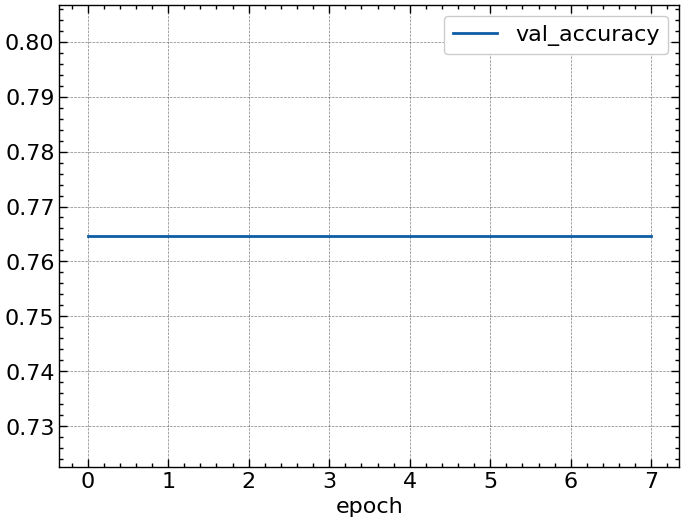

In [29]:
df0.plot(kind='line', x='epoch', y='val_accuracy')